# 14. cross-year fold 랩 (F5~F8)

> 선행 노트북: [13_seasonal_time_fold_lab.ipynb](13_seasonal_time_fold_lab.ipynb)
> 선행 설계서: [06-preprocessing-guardrails.md](../docs/design/06-preprocessing-guardrails.md) 5.2·5.4절

노트북 13은 F0~F4에서 **순위가 5/5 안정**이라고 결론냈고, 같은 문단에서 한계를 적었다.

> 검증 구간이 전부 2024다. 2023을 검증에 쓰면 Group 3 학습 데이터가 사라져
> fold를 만들 수 없다. 즉 "다른 해에서도 유지되는가"는 여전히 답하지 못했다.

이 노트북은 그 한계가 **정말 데이터의 제약인지**부터 다시 묻는다.

**연구 질문**

> 검증 구간을 2024 밖으로 옮기는 fold를 만들 수 있는가?
> 만들 수 있다면, 프리셋 4종의 순위는 다른 해에서도 유지되는가?

두 질문의 순서가 중요하다. 첫 질문에 "만들 수 없다"고 답하면 두 번째는 열리지 않는다.
그리고 **"만들 수 없다"는 판정 자체가 검증 대상**이다. 노트북 13이 그 판정을 내릴 때
가정한 것은 "검증 구간 = 2023년 달력 전체"였고, 그 가정을 풀면 답이 달라진다.

이 노트북이 확인할 순서다.

| 절 | 질문 |
|----|------|
| 1 | Group 3의 2022 공백을 우회할 방법이 정말 없는가 |
| 2 | 2024 밖을 검증하는 fold를 어떻게 정의하는가 |
| 3 | 그 fold에서 프리셋 순위가 유지되는가 |
| 4 | 유지되지 않는다면, 그것이 잡음인가 실제인가 |
| 5 | 연도는 계절·학습 창과 비교해 얼마나 흔드는가 |

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import font_manager


def resolveProjectRoot():
  """worktree/일반 체크아웃 어디서 실행하든 src를 찾는다."""
  here = Path.cwd().resolve()
  for candidate in [here, *here.parents]:
    if (candidate / "src" / "baram").is_dir():
      return candidate
  raise RuntimeError("src/baram을 찾지 못했습니다")


def resolveOfficialDataDir(projectRoot):
  for candidate in [projectRoot, *projectRoot.parents]:
    dataDir = candidate / "data" / "raw" / "open"
    if (dataDir / "train" / "train_labels.csv").is_file():
      return dataDir
  raise RuntimeError("공식 데이터 디렉터리를 찾지 못했습니다")


projectRoot = resolveProjectRoot()
if str(projectRoot / "src") not in sys.path:
  sys.path.insert(0, str(projectRoot / "src"))
dataDir = resolveOfficialDataDir(projectRoot)

sns.set_theme(style="whitegrid")
fontCandidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"]
availableFonts = {font.name for font in font_manager.fontManager.ttflist}
selectedFont = next((font for font in fontCandidates if font in availableFonts), "DejaVu Sans")
plt.rcParams["font.family"] = selectedFont
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")

print(f"project root : {projectRoot.name}")
print(f"official data: {dataDir}")
print(f"한글 폰트    : {selectedFont}")

project root : gbm-cross-year-validation-0327b1
official data: C:\Users\kik32\workspace\Dacon\baram-2026-wind-power-forecasting\data\raw\open
한글 폰트    : Malgun Gothic


09~13과 같은 탐색 규약이다. 이 노트북은 `outputs/`에 아무것도 쓰지 않으므로
모델·제출물·run 기록이 생기지 않는다. 원자료와 라벨은 읽기만 한다.

---

## 1. 2022 공백을 우회할 방법이 있는가

Group 3은 2022년 라벨이 없다. 노트북 13이 여기서 멈췄지만, 멈추기 전에 확인할 것이
하나 더 있다 — **SCADA다.** Group 3은 UNISON U136 5기이고 SCADA에는 터빈별 10분 power가
있다. 2022년 SCADA가 있다면 시간별로 합산해 Group 3의 2022 학습 라벨을 복원할 수 있다.

라벨과 SCADA의 연도별 커버리지를 함께 본다.

In [2]:
from baram.metrics import CAPACITY_KWH, TARGET_COLS

readOfficial = lambda relativePath: pd.read_csv(dataDir / relativePath, encoding="utf-8-sig")

trainLabels = readOfficial("train/train_labels.csv")
trainLabels["kst_dtm"] = pd.to_datetime(trainLabels["kst_dtm"])
labelYear = trainLabels["kst_dtm"].dt.year

labelCoverage = pd.DataFrame(
  {column: trainLabels.groupby(labelYear)[column].apply(lambda values: int(values.notna().sum()))
   for column in TARGET_COLS}
)
labelCoverage.index.name = "연도"

scadaRows = []
for fileName, prefix in [("scada_unison_train.csv", "unison"), ("scada_vestas_train.csv", "vestas")]:
  scada = readOfficial(f"train/{fileName}")
  scada["kst_dtm"] = pd.to_datetime(scada["kst_dtm"])
  powerColumns = [column for column in scada.columns if column.endswith("_power_kw10m")]
  perYear = scada.groupby(scada["kst_dtm"].dt.year).size()
  scadaRows.append({
    "파일": fileName,
    "대응 그룹": "Group 3" if prefix == "unison" else "Group 1·2",
    "터빈 수": len(powerColumns),
    "첫 계측": scada["kst_dtm"].min(),
    "2022 행": int(perYear.get(2022, 0)),
    "2023 행": int(perYear.get(2023, 0)),
    "2024 행": int(perYear.get(2024, 0)),
  })
scadaCoverage = pd.DataFrame(scadaRows).set_index("파일")

print("라벨 연도별 non-null 행 수")
display(labelCoverage)
print("SCADA 커버리지")
display(scadaCoverage)

unisonHas2022 = int(scadaCoverage.loc["scada_unison_train.csv", "2022 행"]) > 0
print(f"\nGroup 3 라벨을 SCADA로 복원할 수 있는가 : {unisonHas2022}")

라벨 연도별 non-null 행 수


,kpx_group_1,kpx_group_2,kpx_group_3
연도,,,
2022,8664,8664,0
2023,8757,8758,8759
2024,8778,8778,8778
2025,1,1,1


SCADA 커버리지


,대응 그룹,터빈 수,첫 계측,2022 행,2023 행,2024 행
파일,,,,,,
scada_unison_train.csv,Group 3,5,2023-01-01 00:10:00,0,52559,52704
scada_vestas_train.csv,Group 1·2,12,2022-01-01 01:00:00,52554,52560,52704



Group 3 라벨을 SCADA로 복원할 수 있는가 : False


### 1-1. Group 3의 2022는 어떤 형태로도 존재하지 않는다

`scada_unison_train.csv`는 **2023-01-01에 시작한다.** VESTAS(Group 1·2)는 2022년 전체가
있는데 UNISON만 없다. 라벨이 비어 있는 게 아니라 **단지 자체의 데이터가 없다** —
프록시 라벨 복원, 터빈 power 합산, 어떤 우회로도 열리지 않는다.

노트북 13의 판정은 이 지점까지는 옳다. **그러나 판정이 한 걸음 더 나갔다.**

> "2023을 검증에 쓰면 Group 3 학습 데이터가 사라져 fold를 만들 수 없다"

이 문장이 참이려면 **검증 구간이 2023년 달력 전체**여야 한다. 그래야 학습 창이
2022 안에 갇히고 Group 3 라벨이 0행이 된다. 검증을 2023년 안에서 자르면 조건이 달라진다 —
2023년 전반을 학습하고 후반을 검증하면 Group 3에도 학습 라벨이 생긴다.

이 관찰에서 fold 네 개가 나온다.

In [3]:
from baram.folds import (
  BACKWARD, FOLDS, FORWARD, RANK_THRESHOLD, TRAIN_WINDOWS,
  assert_fold_contract, describe_folds, group_error_terms, label_mask,
  paired_bootstrap_gap, run_window, score_fold, scoreable_targets,
  total_from_terms, weather_slice, window_predict_ranges,
)

foldFrame = describe_folds(trainLabels)
contractOk = assert_fold_contract(trainLabels)

print(f"fold 계약(비겹침·시간 순서·채점 그룹 존재) 통과 : {contractOk}")
print(f"검증 연도 : {sorted({spec.valid_year for spec in FOLDS.values()})}")
print(f"학습 창   : {len(window_predict_ranges())}종 → 프리셋 4종이면 학습 {4 * len(window_predict_ranges())}회")
display(foldFrame.drop(columns=["목적"]))
display(foldFrame[["목적"]])

fold 계약(비겹침·시간 순서·채점 그룹 존재) 통과 : True
검증 연도 : [2022, 2023, 2024]
학습 창   : 6종 → 프리셋 4종이면 학습 24회


,방향,검증 연도,train 창,train,valid,train 행,G3 train 라벨,valid 행,채점 그룹,겹침 행
fold,,,,,,,,,,
F0,순,2024,W_2022_2023,2022-01-01 ~ 2023-12-31,2024-01-01 ~ 2024-12-31,17519,8759,8784,3,0
F1,순,2024,W_2022_2023,2022-01-01 ~ 2023-12-31,2024-01-01 ~ 2024-05-31,17519,8759,3648,3,0
F2,순,2024,W_2022_2023,2022-01-01 ~ 2023-12-31,2024-06-01 ~ 2024-10-31,17519,8759,3672,3,0
F3,순,2024,W_2023,2023-01-01 ~ 2023-12-31,2024-01-01 ~ 2024-12-31,8759,8759,8784,3,0
F4,순,2024,W_2023_2024H1,2023-01-01 ~ 2024-06-30,2024-07-01 ~ 2024-12-31,13127,13127,4416,3,0
F5,순,2023,W_2022_2023H1,2022-01-01 ~ 2023-06-30,2023-07-01 ~ 2023-12-31,13103,4343,4416,3,0
F6,역,2023,W_2024,2024-01-01 ~ 2024-12-31,2023-01-01 ~ 2023-12-31,8784,8778,8759,3,0
F7,순,2023,W_2022,2022-01-01 ~ 2022-12-31,2023-01-01 ~ 2023-12-31,8759,0,8759,2,0
F8,역,2022,W_2023,2023-01-01 ~ 2023-12-31,2022-01-01 ~ 2022-12-31,8759,8759,8759,2,0


,목적
fold,
F0,기존 기준선 (노트북 08·11·12)
F1,겨울·봄 저온/강풍
F2,여름·가을 장마/저풍속
F3,2022 제거 영향
F4,최신 분포 rolling
F5,F4의 연도 미러 — 계절·창 길이 고정
F6,2023 전체 · 3그룹 (역방향 탐침)
F7,2023 전체 · G1·G2 (G3 학습 라벨 없음)
F8,2022 전체 · G1·G2 (역방향 탐침)


### 1-2. F5는 F4의 연도 미러다

새 fold 네 개 중 **F5가 이 노트북의 핵심**이다.

| | 학습 창 | train 행 | G3 train 라벨 | 검증 | valid 행 |
|---|---|---:|---:|---|---:|
| F4 (기존) | 2023-01-01 ~ 2024-06-30 | 13,127 | 13,127 | 2024-07-01 ~ 12-31 | 4,416 |
| **F5 (신규)** | 2022-01-01 ~ 2023-06-30 | 13,103 | 4,343 | 2023-07-01 ~ 12-31 | 4,416 |

계절(7~12월)이 같고, 검증 행 수가 4,416으로 같고, 학습 창 길이는 2024 윤일 하루만
차이 난다. **바뀌는 것은 연도 하나뿐이다.** 노트북 13이 "흔들림의 주범은 계절"이라고
결론냈으므로, 연도 효과를 재려면 계절을 고정해야 한다. F4↔F5가 그 대조군이다.

나머지 셋은 F5가 못 덮는 곳을 메운다.

- **F6** — 2023년 **전체**를 3그룹으로 검증한다. train이 2024라 시간 순서가 뒤집힌다
- **F7** — 2023년 전체를 순방향으로 검증한다. train이 2022뿐이라 **Group 3이 빠진다**
- **F8** — **2022년**을 검증한다. 검증 연도를 하나 더 늘리지만 역방향이고 2그룹이다

F6·F8은 순방향이 아니다. 이 선택의 근거를 아래에서 따로 적는다.

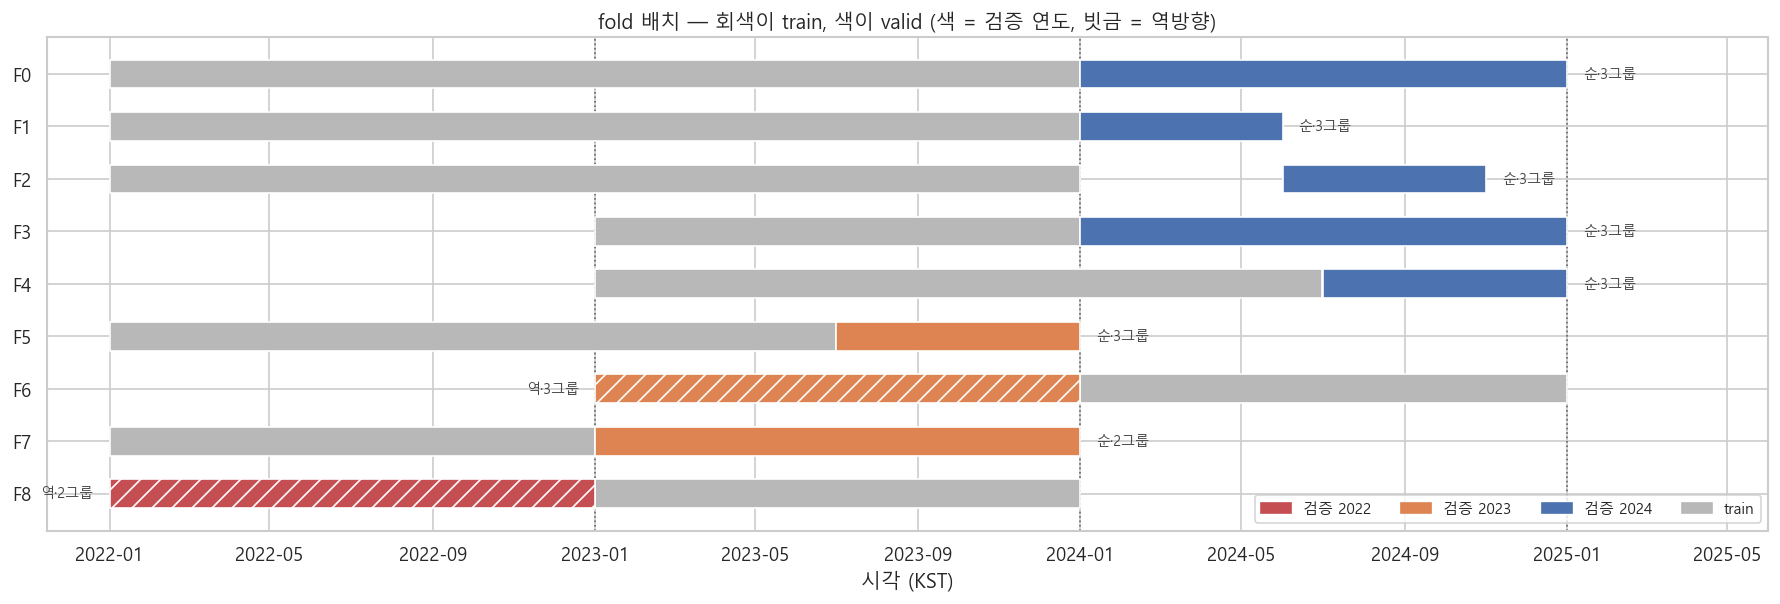

In [4]:
yearColor = {2022: "#c44e52", 2023: "#dd8452", 2024: "#4c72b0"}
fig, axis = plt.subplots(figsize=(15, 5.2))
for position, (foldName, spec) in enumerate(reversed(list(FOLDS.items()))):
  trainStart, trainEnd = TRAIN_WINDOWS[spec.train_window]
  trainStart, trainEnd = pd.Timestamp(trainStart), pd.Timestamp(trainEnd)
  validStart, validEnd = pd.Timestamp(spec.valid_start), pd.Timestamp(spec.valid_end)
  axis.barh(position, trainEnd - trainStart, left=trainStart, height=0.55,
            color="#b8b8b8", edgecolor="white", zorder=2)
  axis.barh(position, validEnd - validStart, left=validStart, height=0.55,
            color=yearColor[spec.valid_year], edgecolor="white", zorder=3,
            hatch="//" if spec.direction == BACKWARD else None)
  # 역방향 fold는 valid 오른쪽에 train이 붙으므로 라벨을 왼쪽에 둔다.
  groupCount = len(scoreable_targets(trainLabels, foldName))
  caption = f"{spec.direction}·{groupCount}그룹"
  if spec.direction == BACKWARD:
    axis.text(validStart - pd.Timedelta(days=12), position, caption,
              va="center", ha="right", fontsize=8.5, color="#444444")
  else:
    axis.text(validEnd + pd.Timedelta(days=12), position, caption,
              va="center", ha="left", fontsize=8.5, color="#444444")

axis.set_yticks(range(len(FOLDS)))
axis.set_yticklabels(list(reversed(list(FOLDS))))
axis.set_xlim(pd.Timestamp("2021-11-15"), pd.Timestamp("2025-06-01"))
for boundary in ["2023-01-01", "2024-01-01", "2025-01-01"]:
  axis.axvline(pd.Timestamp(boundary), color="#666666", linestyle=":", linewidth=1, zorder=1)
axis.set_title("fold 배치 — 회색이 train, 색이 valid (색 = 검증 연도, 빗금 = 역방향)", fontsize=12)
axis.set_xlabel("시각 (KST)")
handles = [plt.Rectangle((0, 0), 1, 1, color=yearColor[year]) for year in [2022, 2023, 2024]]
handles.append(plt.Rectangle((0, 0), 1, 1, color="#b8b8b8"))
axis.legend(handles, ["검증 2022", "검증 2023", "검증 2024", "train"], loc="lower right", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

그림에서 F0~F4의 색이 전부 같다. **노트북 13이 잰 다섯 fold는 검증 연도가 하나였다.**
F5~F8이 처음으로 다른 색을 넣는다.

### Decision Box ㉒ — 역방향 fold를 쓰되, 순위 탐침으로만 쓴다

**선택지**

- (A) 순방향 fold만 쓴다. 검증 연도는 2023 후반(F5)과 2023 전체·2그룹(F7)까지만 넓어진다
- (B) 역방향 fold(F6·F8)를 함께 쓰되 용도를 순위 탐침으로 제한한다
- (C) 역방향 fold를 순방향과 동등하게 쓴다

**근거**

역방향 fold는 미래로 과거를 맞히므로, 일반적인 시계열 평가에서는 금지에 가깝다.
그런데 **금지의 이유가 이 저장소에 해당하는지**를 따져야 한다. 금지 이유는 두 가지다.

1. **자기회귀 통로** — lag·rolling 피처가 있으면 미래 학습이 과거 타깃을 직접 들여다본다
2. **운영 불가능성** — 실제 운영에서는 미래 데이터를 쓸 수 없으므로 수준 추정이 낙관 편향된다

1번은 이 저장소에 없다. 노트북 13 2절이 `shift`·`rolling`·`expanding`·`ewm`·`diff`·`cum*`를
**0건**으로 확인했고, 설계서 06 2.3절이 라벨 파생 피처가 하나도 없음을 계약으로 두었다.
피처는 전부 `forecast_kst_dtm` 한 행에서 NWP와 달력으로만 만들어진다. 타깃이 흘러들 통로가 없다.

2번은 **남는다.** 2024로 학습한 모델은 2023을 맞힐 때 실제 운영에서 못 가졌을 정보를
가진다. 그래서 F6·F8의 **점수 수준은 신뢰할 수 없다.**

그러나 이 노트북이 묻는 것은 수준이 아니라 순위다. 그리고 노트북 13이 이미
"fold를 넘나들며 절대 점수를 비교하면 안 되고 같은 fold 안의 차이만 봐야 한다"고
결론냈으므로, 수준을 안 쓰는 것은 새로운 제약이 아니다.

**채택: (B)** — 운영 규칙은 다음과 같다.

| 용도 | 순방향 (F0~F5, F7) | 역방향 (F6·F8) |
|------|-------------------|----------------|
| 같은 fold 안의 순위·부호 | 사용 | **사용** |
| 개선분 크기의 대표값 | 사용 | 사용하지 않음 |
| 문턱(SD) 계산 | 사용 | 참고만 |
| 제출 판단 기준선 | 사용 | 사용하지 않음 |

역방향 fold의 결론이 순방향과 어긋나면, 어긋난다는 사실 자체를 보고하고
순방향 쪽을 채택한다.

---

## 2. 2022 학습 창에 품질 페널티가 없는가

F5·F7은 2022년을 학습에 쓴다. 설계서 05 R5가 2025 test에서 LDAPS 변수 47쌍이 전 격자
결측이라고 기록했으므로, **2022 train에도 같은 문제가 있으면** F5의 낮은 점수가 연도
때문인지 결측 때문인지 구분할 수 없게 된다. 먼저 확인한다.

In [5]:
qualityRows = []
weatherFrames = {}
for fileName in ["ldaps_train.csv", "gfs_train.csv"]:
  frame = readOfficial(f"train/{fileName}")
  frame["forecast_kst_dtm"] = pd.to_datetime(frame["forecast_kst_dtm"])
  frame["data_available_kst_dtm"] = pd.to_datetime(frame["data_available_kst_dtm"])
  weatherFrames[fileName] = frame
  variableColumns = [
    column for column in frame.columns
    if column not in {"forecast_kst_dtm", "data_available_kst_dtm", "grid_id", "latitude", "longitude"}
  ]
  cutoffViolations = int((frame["data_available_kst_dtm"] > frame["forecast_kst_dtm"]).sum())
  for year, yearFrame in frame.groupby(frame["forecast_kst_dtm"].dt.year):
    if year == 2025:
      continue
    nanRate = yearFrame[variableColumns].isna().mean()
    qualityRows.append({
      "파일": fileName, "연도": year, "행 수": len(yearFrame), "변수 수": len(variableColumns),
      "평균 NaN율": float(nanRate.mean()),
      "전 격자 결측 변수": int((nanRate == 1.0).sum()),
      "cutoff 위반": cutoffViolations,
    })
qualityFrame = pd.DataFrame(qualityRows).set_index(["파일", "연도"])
display(qualityFrame)

cleanAcrossYears = bool((qualityFrame["평균 NaN율"] == 0).all() and (qualityFrame["cutoff 위반"] == 0).all())
print(f"전 연도 NWP가 결측 0·cutoff 위반 0인가 : {cleanAcrossYears}")

ldapsTrain, gfsTrain = weatherFrames["ldaps_train.csv"], weatherFrames["gfs_train.csv"]

행 수  변수 수  평균 NaN율  전 격자 결측 변수  cutoff 위반
파일              연도                                                
ldaps_train.csv 2022  140144    30 0.000000           0          0
                2023  140160    30 0.000000           0          0
                2024  140544    30 0.000000           0          0
gfs_train.csv   2022   78831    35 0.000000           0          0
                2023   78840    35 0.000000           0          0
                2024   79056    35 0.000000           0          0

전 연도 NWP가 결측 0·cutoff 위반 0인가 : True


### 2-1. 2022 창은 2023·2024와 같은 품질이다

세 연도 모두 **NaN 0건, cutoff 위반 0건**이다. 설계서 05 R5가 기록한 24% 결측은
**2025 test 전용**이며 train에는 없다. F5·F7이 2022를 학습에 써도 결측 페널티가 붙지 않는다.

이제 F5의 점수가 F4보다 낮게 나온다면 그것은 결측이 아니라 다른 이유다.

---

## 3. fold 실행

학습 창 6종 × 프리셋 4종 = **모델 학습 24회**다. 같은 창을 쓰는 fold는 예측을 공유한다.

fold runner는 노트북 13이 로컬로 들고 있던 코드를 `src/baram/folds.py`로 승격한 것이다.
승격이 맞는지는 **F0가 노트북 08·11·12·13의 값을 그대로 재현하는가**로 판정한다.

In [6]:
from baram.feature_config import get_feature_set
from baram.features.turbine_metadata import load_turbine_locations

PRESETS = ["official_mean", "expanded_vector", "spatial_idw2_all_group", "spatial_nearest_own_group"]
CONTROL, CANDIDATE, RUNNER_UP = "official_mean", "spatial_idw2_all_group", "spatial_nearest_own_group"

turbines = load_turbine_locations(dataDir / "info.xlsx")
predictionCache, featureCounts = {}, {}
totalStarted = time.perf_counter()
for presetName in PRESETS:
  config = get_feature_set(presetName)
  for windowName, (predictStart, predictEnd) in window_predict_ranges().items():
    started = time.perf_counter()
    result = run_window(
      config, windowName, predictStart, predictEnd,
      labels=trainLabels, ldaps=ldapsTrain, gfs=gfsTrain, turbine_locations=turbines,
    )
    predictionCache[(presetName, windowName)] = result.predictions
    featureCounts[presetName] = result.feature_count
    skipped = ",".join(target[-1] for target in result.skipped_targets) or "-"
    print(f"  {presetName:26s} {windowName:14s} features={result.feature_count:3d}"
          f"  학습 제외 G{skipped}  {time.perf_counter() - started:5.1f}s")
print(f"\n총 학습 {len(predictionCache)}회 · {time.perf_counter() - totalStarted:.1f}s")

REFERENCE_F0 = {
  "official_mean": 0.5777425681025163,
  "expanded_vector": 0.5864824798698839,
  "spatial_idw2_all_group": 0.5924854297224146,
  "spatial_nearest_own_group": 0.5898283700164271,
}
GATE_TOLERANCE = 1e-9
gateRows = []
for presetName, expected in REFERENCE_F0.items():
  reproduced = float(score_fold(trainLabels, predictionCache[(presetName, FOLDS["F0"].train_window)], "F0")[0])
  difference = abs(reproduced - expected)
  gateRows.append({"preset": presetName, "F0 재현": reproduced, "노트북 13 기준": expected,
                   "절대 차이": difference, "판정": "통과" if difference <= GATE_TOLERANCE else "실패"})
gateFrame = pd.DataFrame(gateRows).set_index("preset")
promotionOk = bool((gateFrame["판정"] == "통과").all())
print(f"\nF0 재현 게이트({GATE_TOLERANCE:.0e}) 통과 : {promotionOk}")
with pd.option_context("display.float_format", lambda value: f"{value:.16g}"):
  display(gateFrame)

  official_mean              W_2022_2023    features= 76  학습 제외 G-    2.5s


  official_mean              W_2023         features= 76  학습 제외 G-    2.0s


  official_mean              W_2023_2024H1  features= 76  학습 제외 G-    2.1s


  official_mean              W_2022_2023H1  features= 76  학습 제외 G-    1.8s


  official_mean              W_2024         features= 76  학습 제외 G-    1.7s


...

  spatial_nearest_own_group  W_2023_2024H1  features=550  학습 제외 G-    9.9s


  spatial_nearest_own_group  W_2022_2023H1  features=550  학습 제외 G-    8.6s


  spatial_nearest_own_group  W_2024         features=550  학습 제외 G-    8.1s


  spatial_nearest_own_group  W_2022         features=550  학습 제외 G3    7.2s

총 학습 24회 · 156.1s

F0 재현 게이트(1e-09) 통과 : True


,F0 재현,노트북 13 기준,절대 차이,판정
preset,,,,
official_mean,0.5777425681025163,0.5777425681025163,0,통과
expanded_vector,0.5864824798698839,0.5864824798698839,0,통과
spatial_idw2_all_group,0.5924854297224146,0.5924854297224146,0,통과
spatial_nearest_own_group,0.5898283700164271,0.5898283700164271,0,통과


### 3-1. 승격한 runner가 같은 답을 낸다

프리셋 4종 전부 **절대 차이 0.0**이다. `src/baram/folds.py`는 노트북 13 코드의 이동이지
재작성이 아니며, F5~F8의 숫자도 같은 코드 경로에서 나온다.

이제 아홉 fold를 채점한다. 채점 그룹은 fold마다 자동으로 정해진다 — F7·F8은 Group 3의
라벨이 없으므로 2그룹으로 채점된다. **그룹 수가 다른 점수끼리는 수준을 비교하지 않고,
같은 fold 안의 차이만 본다.**

In [7]:
scoreRows = []
for presetName in PRESETS:
  for foldName, spec in FOLDS.items():
    columns = scoreable_targets(trainLabels, foldName)
    total, oneMinusNmae, ficr = score_fold(
      trainLabels, predictionCache[(presetName, spec.train_window)], foldName, columns=columns
    )
    scoreRows.append({
      "fold": foldName, "preset": presetName, "검증 연도": spec.valid_year, "방향": spec.direction,
      "그룹 수": len(columns), "total_score": total, "one_minus_nmae": oneMinusNmae, "ficr": ficr,
    })
scoreFrame = pd.DataFrame(scoreRows)
foldOrder = list(FOLDS)
totalPivot = scoreFrame.pivot(index="preset", columns="fold", values="total_score").loc[PRESETS, foldOrder]
rankPivot = totalPivot.rank(ascending=False, axis=0).astype(int)

foldMeta = scoreFrame.drop_duplicates("fold").set_index("fold").loc[foldOrder, ["검증 연도", "방향", "그룹 수"]]
print("fold별 total_score")
display(totalPivot)
print("fold별 순위 (1 = 최고)")
display(rankPivot)
display(foldMeta.T)

rankStable2024 = bool((rankPivot[["F0", "F1", "F2", "F3", "F4"]].nunique(axis=1) == 1).all())
rankStableAll = bool((rankPivot.nunique(axis=1) == 1).all())
print(f"2024 fold 5개에서 순위가 동일한가 : {rankStable2024}")
print(f"9개 fold 전부에서 순위가 동일한가 : {rankStableAll}")
print(f"채택 후보가 모든 fold에서 1위인가 : {bool((rankPivot.loc[CANDIDATE] == 1).all())}")

fold별 total_score


fold,F0,F1,F2,F3,F4,F5,F6,F7,F8
preset,,,,,,,,,
official_mean,0.577743,0.565757,0.589845,0.573929,0.571226,0.555391,0.560935,0.561265,0.588143
expanded_vector,0.586482,0.581939,0.595021,0.587382,0.576610,0.562739,0.573804,0.573013,0.596418
spatial_idw2_all_group,0.592485,0.587199,0.602347,0.591831,0.585001,0.565869,0.574425,0.573263,0.599698
spatial_nearest_own_group,0.589828,0.584091,0.601383,0.588510,0.581693,0.565412,0.574596,0.572281,0.599694


fold별 순위 (1 = 최고)


fold,F0,F1,F2,F3,F4,F5,F6,F7,F8
preset,,,,,,,,,
official_mean,4,4,4,4,4,4,4,4,4
expanded_vector,3,3,3,3,3,3,3,2,3
spatial_idw2_all_group,1,1,1,1,1,1,2,1,1
spatial_nearest_own_group,2,2,2,2,2,2,1,3,2


fold,F0,F1,F2,F3,F4,F5,F6,F7,F8
검증 연도,2024,2024,2024,2024,2024,2023,2023,2023,2022
방향,순,순,순,순,순,순,역,순,역
그룹 수,3,3,3,3,3,3,3,2,2


2024 fold 5개에서 순위가 동일한가 : True
9개 fold 전부에서 순위가 동일한가 : False
채택 후보가 모든 fold에서 1위인가 : False


숫자를 그림으로 옮긴다. 왼쪽은 fold별 점수 수준, 오른쪽은 순위 궤적이며
배경 음영이 검증 연도를 나눈다.

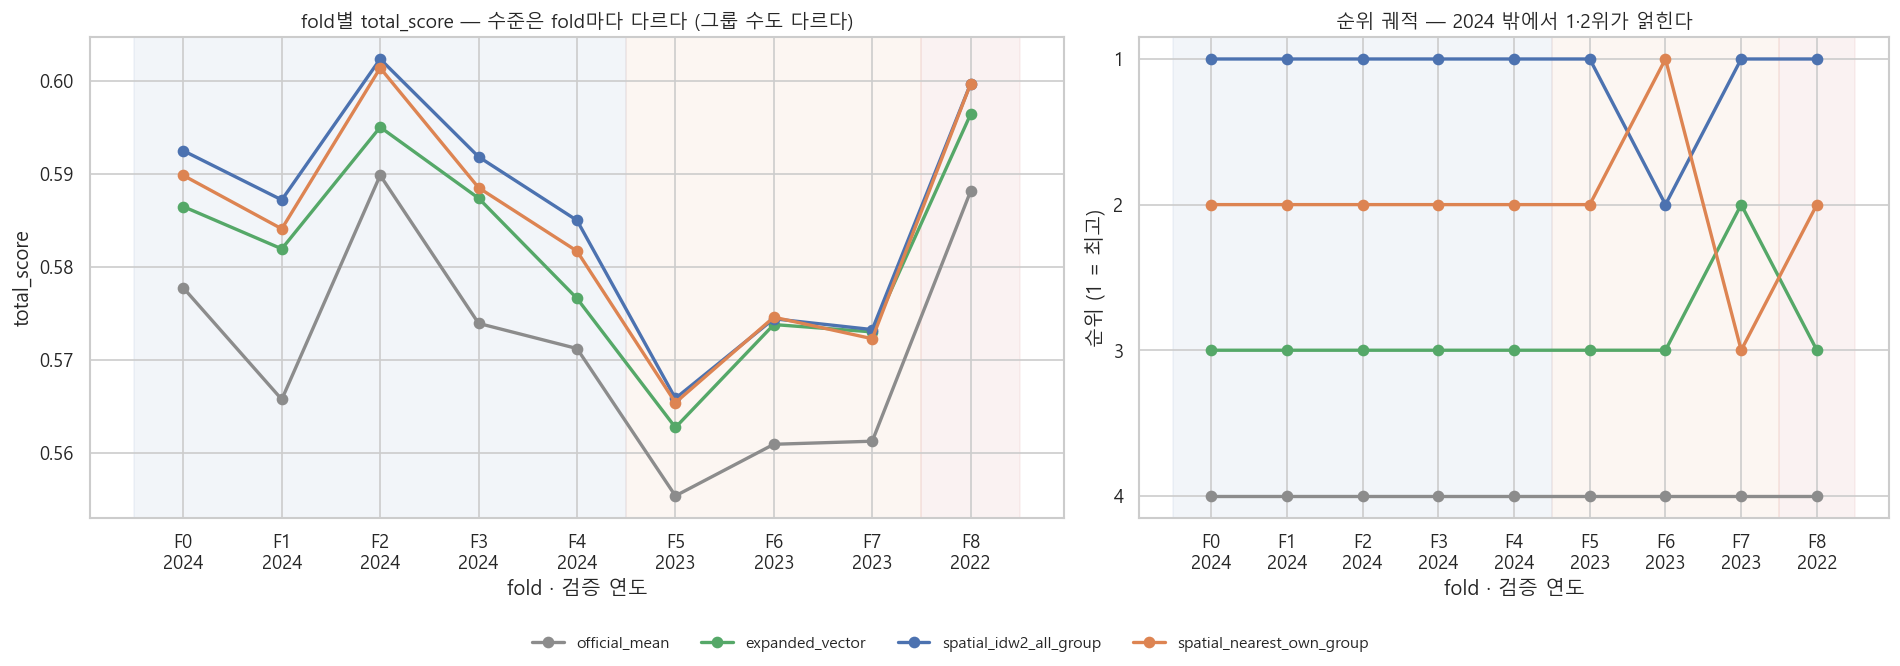

In [8]:
presetColor = dict(zip(PRESETS, ["#8c8c8c", "#55a868", "#4c72b0", "#dd8452"]))
# x축 눈금에 검증 연도를 같이 적는다. 별도 주석을 얹으면 눈금과 겹친다.
foldTickLabels = [f"{name}\n{FOLDS[name].valid_year}" for name in foldOrder]
yearSpan = {}
for foldName in foldOrder:
  yearSpan.setdefault(FOLDS[foldName].valid_year, []).append(foldOrder.index(foldName))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.6), gridspec_kw={"width_ratios": [1.3, 1]})
for axis in axes:
  for year, positions in yearSpan.items():
    axis.axvspan(min(positions) - 0.5, max(positions) + 0.5,
                 color=yearColor[year], alpha=0.07, zorder=0)

for presetName in PRESETS:
  axes[0].plot(foldOrder, totalPivot.loc[presetName], marker="o", label=presetName,
               color=presetColor[presetName], linewidth=2, zorder=3)
  axes[1].plot(foldOrder, rankPivot.loc[presetName], marker="o", label=presetName,
               color=presetColor[presetName], linewidth=2, zorder=3)
axes[0].set_title("fold별 total_score — 수준은 fold마다 다르다 (그룹 수도 다르다)", fontsize=11.5)
axes[0].set_ylabel("total_score")
axes[1].set_title("순위 궤적 — 2024 밖에서 1·2위가 얽힌다", fontsize=11.5)
axes[1].set_ylabel("순위 (1 = 최고)")
axes[1].set_yticks([1, 2, 3, 4])
axes[1].invert_yaxis()
for axis in axes:
  axis.set_xlabel("fold · 검증 연도")
  axis.set_xticks(range(len(foldOrder)))
  axis.set_xticklabels(foldTickLabels)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9.5, frameon=False)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

### 4-1. 순위는 절반만 유지된다

오른쪽 패널의 회색 선(통제군)은 아홉 fold 내내 바닥에 붙어 있다. **`official_mean`이
최하위라는 사실은 어느 해에서도 흔들리지 않는다.** 채택 후보가 통제군을 이긴다는
주 결론이 여기에 걸려 있고, 그 결론은 살아남는다.

무너지는 것은 위쪽이다. 파란 선과 주황 선이 F6에서 교차하고 F7에서 다시 얽힌다.
**2024 밖으로 나가자마자 1·2위가 뒤섞인다.**

노트북 13은 "5개 fold 전부 동일"을 근거로 부호 일치 5/5를 보고했다. 그 다섯이
모두 같은 해를 검증했다는 사실이 이 그림에서 드러난다.

---

## 5. 뒤집힘은 잡음인가 실제인가

순위가 바뀌었다고 곧바로 "2023에서는 2위가 더 낫다"고 말하면 안 된다.
간격이 워낙 작으면 뒤집힘 자체가 표집 잡음일 수 있다. 크기부터 잰다.

In [9]:
deltaPivot = totalPivot - totalPivot.loc[CONTROL]
candidateDelta = deltaPivot.loc[CANDIDATE]
gapTopTwo = totalPivot.loc[CANDIDATE] - totalPivot.loc[RUNNER_UP]
forwardFolds = [name for name, spec in FOLDS.items() if spec.direction == FORWARD]
folds2024 = ["F0", "F1", "F2", "F3", "F4"]

print("통제군 대비 Δ (fold별)")
display(deltaPivot.drop(index=CONTROL).loc[:, foldOrder])

summaryRows = []
for label, names in [("2024 전용 (노트북 13)", folds2024), ("순방향 7개", forwardFolds), ("전체 9개", foldOrder)]:
  delta, gap = candidateDelta[names], gapTopTwo[names]
  summaryRows.append({
    "fold 집합": label, "개수": len(names),
    "채택 후보 Δ 평균": delta.mean(), "Δ 최소": delta.min(), "Δ 최대": delta.max(),
    "Δ SD": delta.std(ddof=1),
    "1·2위 간격 평균": gap.mean(), "부호 일치": f"{int((gap > 0).sum())}/{len(gap)}",
  })
display(pd.DataFrame(summaryRows).set_index("fold 집합"))

print(f"순위 문턱 (노트북 13) : {RANK_THRESHOLD}")
print(f"채택 후보 Δ 최솟값    : {candidateDelta.min():.6f}  → 문턱의 {candidateDelta.min() / RANK_THRESHOLD:.1f}배")
print(f"1·2위 간격 최댓값     : {gapTopTwo.max():.6f}  → 문턱의 {gapTopTwo.max() / RANK_THRESHOLD:.2f}배")
print()
print("1·2위 간격 (fold별)")
display(gapTopTwo.to_frame("간격").T)

통제군 대비 Δ (fold별)


fold,F0,F1,F2,F3,F4,F5,F6,F7,F8
preset,,,,,,,,,
expanded_vector,0.008740,0.016182,0.005176,0.013453,0.005385,0.007347,0.012869,0.011748,0.008276
spatial_idw2_all_group,0.014743,0.021442,0.012503,0.017902,0.013775,0.010477,0.013490,0.011998,0.011555
spatial_nearest_own_group,0.012086,0.018334,0.011539,0.014581,0.010468,0.010020,0.013661,0.011016,0.011552


,개수,채택 후보 Δ 평균,Δ 최소,Δ 최대,Δ SD,1·2위 간격 평균,부호 일치
fold 집합,,,,,,,
2024 전용 (노트북 13),5,0.016073,0.012503,0.021442,0.003605,0.002672,5/5
순방향 7개,7,0.014691,0.010477,0.021442,0.003797,0.002114,7/7
전체 9개,9,0.014210,0.010477,0.021442,0.003459,0.001626,8/9


순위 문턱 (노트북 13) : 0.0036
채택 후보 Δ 최솟값    : 0.010477  → 문턱의 2.9배
1·2위 간격 최댓값     : 0.003321  → 문턱의 0.92배

1·2위 간격 (fold별)


fold,F0,F1,F2,F3,F4,F5,F6,F7,F8
간격,0.002657,0.003108,0.000964,0.003321,0.003308,0.000457,-0.000171,0.000982,0.000004


### 5-1. 문턱은 그대로 두면 되고, 부호 일치는 무너진다

두 결과가 갈린다.

**문턱은 유지된다.** 채택 후보 Δ의 fold 간 SD가 2024 전용 5개에서 0.0036, 순방향 7개에서
0.0038, 전체 9개에서 0.0035다. 노트북 13이 정한 **0.0036이 그 사이에 있다.**
검증 연도를 셋으로 늘려도 문턱을 고칠 이유가 없다.

**주 결론도 유지된다.** 채택 후보 Δ가 아홉 fold 전부 양수이고 최솟값이 문턱의 2.9배다.

**부호 일치는 무너진다.** 1·2위 간격의 부호가 5/5에서 **8/9**로 떨어졌다. 그리고
2023·2022 fold의 간격은 0.000004~0.000982로, 2024 fold의 0.000964~0.003321보다 확연히 작다.

간격이 이렇게 작으면 **fold 안에서도 잡음과 구분되지 않을 것**이다. 노트북 12가
Public 40% 표본에 쓴 paired bootstrap을 fold 내부에 적용해 확인한다.

In [10]:
BOOTSTRAP_DRAWS = 4000
bootstrapRows = []
bootstrapGaps = {}
bootStarted = time.perf_counter()
for foldName in foldOrder:
  columns = scoreable_targets(trainLabels, foldName)
  windowName = FOLDS[foldName].train_window
  termsCandidate = group_error_terms(trainLabels, predictionCache[(CANDIDATE, windowName)], foldName, columns)
  termsRunnerUp = group_error_terms(trainLabels, predictionCache[(RUNNER_UP, windowName)], foldName, columns)
  termsControl = group_error_terms(trainLabels, predictionCache[(CONTROL, windowName)], foldName, columns)

  gaps = paired_bootstrap_gap(termsCandidate, termsRunnerUp, draws=BOOTSTRAP_DRAWS)
  deltas = paired_bootstrap_gap(termsCandidate, termsControl, draws=BOOTSTRAP_DRAWS)
  bootstrapGaps[foldName] = gaps
  bootstrapRows.append({
    "fold": foldName, "검증 연도": FOLDS[foldName].valid_year, "방향": FOLDS[foldName].direction,
    "1·2위 간격": float(gapTopTwo[foldName]), "간격 SD": float(gaps.std(ddof=1)),
    "P(간격>0)": float((gaps > 0).mean()),
    "채택−통제 Δ": float(candidateDelta[foldName]), "P(Δ>0)": float((deltas > 0).mean()),
  })
bootstrapFrame = pd.DataFrame(bootstrapRows).set_index("fold")
display(bootstrapFrame)
print(f"bootstrap {BOOTSTRAP_DRAWS}회 × {len(foldOrder)} fold × 2쌍 · {time.perf_counter() - bootStarted:.1f}s")
print()
print(f"채택−통제 Δ가 전 fold에서 P>0.99인가 : {bool((bootstrapFrame['P(Δ>0)'] > 0.99).all())}")
print("1·2위 P(간격>0) — 2024 fold :", ", ".join(f"{bootstrapFrame.loc[f, 'P(간격>0)']:.3f}" for f in folds2024))
print("1·2위 P(간격>0) — 그 외      :", ", ".join(
  f"{f} {bootstrapFrame.loc[f, 'P(간격>0)']:.3f}" for f in foldOrder if f not in folds2024))

,검증 연도,방향,1·2위 간격,간격 SD,P(간격>0),채택−통제 Δ,P(Δ>0)
fold,,,,,,,
F0,2024,순,0.002657,0.000989,0.996500,0.014743,1.000000
F1,2024,순,0.003108,0.001529,0.978000,0.021442,1.000000
F2,2024,순,0.000964,0.001657,0.718750,0.012503,1.000000
F3,2024,순,0.003321,0.001018,0.999750,0.017902,1.000000
F4,2024,순,0.003308,0.001492,0.988250,0.013775,1.000000
F5,2023,순,0.000457,0.001188,0.670250,0.010477,1.000000
F6,2023,역,-0.000171,0.000961,0.429250,0.013490,1.000000
F7,2023,순,0.000982,0.001085,0.810750,0.011998,1.000000
F8,2022,역,0.000004,0.001186,0.510750,0.011555,1.000000


bootstrap 4000회 × 9 fold × 2쌍 · 38.2s

채택−통제 Δ가 전 fold에서 P>0.99인가 : True
1·2위 P(간격>0) — 2024 fold : 0.997, 0.978, 0.719, 1.000, 0.988
1·2위 P(간격>0) — 그 외      : F5 0.670, F6 0.429, F7 0.811, F8 0.511


### 5-2. bootstrap이 동전 던지기라고 말한다

`P(간격>0)`을 읽는다. 이 값이 0.5 근처면 재표집할 때마다 승자가 바뀐다는 뜻이다.

- **2024 fold** — 0.719 ~ 1.000. F2를 빼면 대체로 한쪽으로 기운다
- **2023·2022 fold** — 0.429 ~ 0.811. F6는 0.5 아래이고 F8은 0.511로 **완전한 동전 던지기**다

반면 `P(Δ>0)`는 아홉 fold 전부 **1.000**이다. 채택 후보가 통제군보다 낫다는 것은
어느 해에서 재든, 어느 표본으로 재든 뒤집히지 않는다.

**두 질문의 답이 다르다.**

> "spatial pooling이 official_mean보다 낫다" → 세 연도에서 확인됨
> "idw2_all_group이 nearest_own_group보다 낫다" → **2024에서만 보이던 것**

그림으로 확인한다.

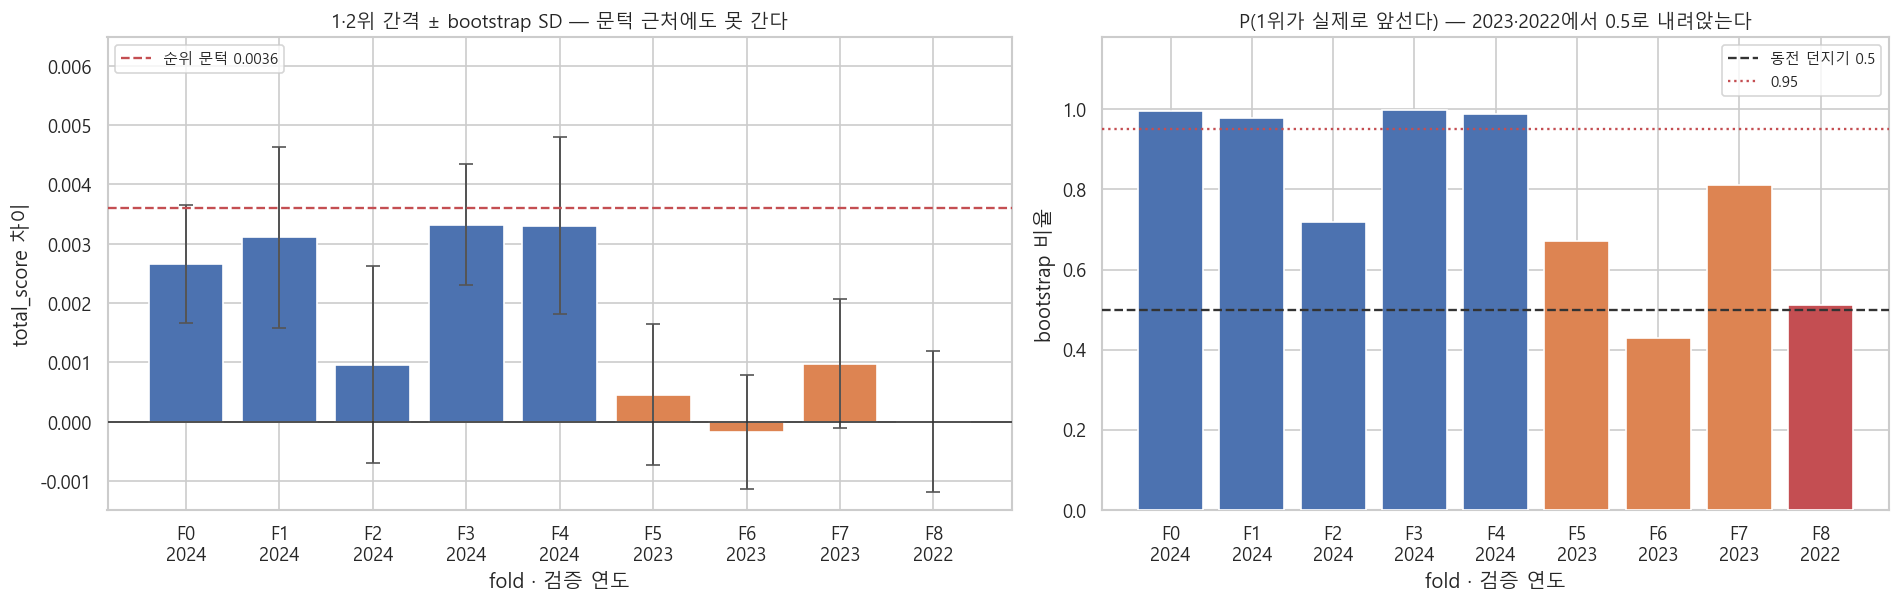

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1.15, 1]})

barColors = [yearColor[FOLDS[name].valid_year] for name in foldOrder]
axes[0].bar(foldOrder, [gapTopTwo[name] for name in foldOrder], color=barColors,
            yerr=[bootstrapFrame.loc[name, "간격 SD"] for name in foldOrder],
            capsize=4, error_kw={"ecolor": "#555555", "linewidth": 1.2}, zorder=3)
axes[0].axhline(0, color="#333333", linewidth=1, zorder=4)
axes[0].axhline(RANK_THRESHOLD, color="#c44e52", linestyle="--", linewidth=1.4, zorder=4,
                label=f"순위 문턱 {RANK_THRESHOLD}")
axes[0].set_title("1·2위 간격 ± bootstrap SD — 문턱 근처에도 못 간다", fontsize=11.5)
axes[0].set_ylabel("total_score 차이")
# 범례가 오차막대 끝을 건드리지 않도록 위쪽 여백을 준다.
axes[0].set_ylim(top=max(gapTopTwo[name] + bootstrapFrame.loc[name, "간격 SD"] for name in foldOrder) * 1.35)
axes[0].legend(fontsize=9, loc="upper left")

probabilities = [bootstrapFrame.loc[name, "P(간격>0)"] for name in foldOrder]
axes[1].bar(foldOrder, probabilities, color=barColors, zorder=3)
axes[1].axhline(0.5, color="#333333", linestyle="--", linewidth=1.4, zorder=4, label="동전 던지기 0.5")
axes[1].axhline(0.95, color="#c44e52", linestyle=":", linewidth=1.4, zorder=4, label="0.95")
axes[1].set_ylim(0, 1.18)
axes[1].set_title("P(1위가 실제로 앞선다) — 2023·2022에서 0.5로 내려앉는다", fontsize=11.5)
axes[1].set_ylabel("bootstrap 비율")
axes[1].legend(fontsize=9, loc="upper right")
for axis in axes:
  axis.set_xlabel("fold · 검증 연도")
  axis.set_xticks(range(len(foldOrder)))
  axis.set_xticklabels(foldTickLabels)
plt.tight_layout()
plt.show()

왼쪽 막대의 오차 범위가 거의 전부 0을 가로지른다. 붉은 점선(문턱)은 훨씬 위에 있다.

---

## 6. 연도는 얼마나 흔드는가

노트북 13은 흔들림을 **계절**과 **학습 창** 두 성분으로 나눴고 계절이 2.2배 크다고 결론냈다.
이제 세 번째 성분을 잴 수 있다.

- **F1·F2** — 학습 창 고정, 검증 계절만 변경 → 계절 성분
- **F0·F3·F4** — 검증 연도 고정, 학습 범위 변경 → 학습 창 성분
- **F4·F5** — 계절·창 길이 고정, **검증 연도만 변경** → 연도 성분

F4↔F5에는 교란이 하나 남는다. Group 3의 학습 라벨이 F4는 13,127행인데 F5는 4,343행이다.
연도 때문인지 Group 3 학습량 때문인지 가르려면 **Group 1·2만으로 다시 채점**하면 된다.
두 그룹은 학습 라벨 수가 13,124 ↔ 13,008로 사실상 같다.

In [12]:
componentRows = []
for label, names, note in [
  ("계절 (모델 고정)", ["F1", "F2"], "학습 창이 F0과 같다. 검증 계절만 다르다"),
  ("학습 창 (연도 고정)", ["F0", "F3", "F4"], "검증이 전부 2024. 학습 범위가 다르다"),
  ("연도 (계절·창 고정)", ["F4", "F5"], "검증이 7~12월로 같다. 연도만 다르다"),
]:
  values = candidateDelta[names]
  componentRows.append({"성분": label, "fold": ", ".join(names), "Δ 최소": values.min(),
                        "Δ 최대": values.max(), "폭": values.max() - values.min(), "비고": note})
componentFrame = pd.DataFrame(componentRows).set_index("성분")
display(componentFrame)

twoGroupRows = []
for presetName in PRESETS:
  for foldName in ["F4", "F5"]:
    total, _, _ = score_fold(trainLabels, predictionCache[(presetName, FOLDS[foldName].train_window)],
                             foldName, columns=TARGET_COLS[:2])
    twoGroupRows.append({"fold": foldName, "preset": presetName, "total_score": total})
twoGroupPivot = pd.DataFrame(twoGroupRows).pivot(index="preset", columns="fold", values="total_score").loc[PRESETS]
twoGroupDelta = (twoGroupPivot - twoGroupPivot.loc[CONTROL]).loc[CANDIDATE]

print("Group 1·2 전용 재채점 — Group 3 학습량 비대칭을 제거한다")
display(twoGroupPivot)
print(f"3그룹   : F4 Δ {candidateDelta['F4']:.6f} → F5 Δ {candidateDelta['F5']:.6f}"
      f"  (차이 {candidateDelta['F5'] - candidateDelta['F4']:+.6f})")
print(f"G1·G2만 : F4 Δ {twoGroupDelta['F4']:.6f} → F5 Δ {twoGroupDelta['F5']:.6f}"
      f"  (차이 {twoGroupDelta['F5'] - twoGroupDelta['F4']:+.6f})")

seasonSpread = float(componentFrame.loc["계절 (모델 고정)", "폭"])
windowSpread = float(componentFrame.loc["학습 창 (연도 고정)", "폭"])
yearSpread = float(componentFrame.loc["연도 (계절·창 고정)", "폭"])
print(f"\n계절 {seasonSpread:.6f} · 학습 창 {windowSpread:.6f} · 연도 {yearSpread:.6f}")
print(f"연도는 학습 창의 {yearSpread / windowSpread:.2f}배, 계절의 {yearSpread / seasonSpread:.2f}배")

,fold,Δ 최소,Δ 최대,폭,비고
성분,,,,,
계절 (모델 고정),"F1, F2",0.012503,0.021442,0.008940,학습 창이 F0과 같다. 검증 계절만 다르다
학습 창 (연도 고정),"F0, F3, F4",0.013775,0.017902,0.004126,검증이 전부 2024. 학습 범위가 다르다
연도 (계절·창 고정),"F4, F5",0.010477,0.013775,0.003298,검증이 7~12월로 같다. 연도만 다르다


Group 1·2 전용 재채점 — Group 3 학습량 비대칭을 제거한다


fold,F4,F5
preset,,
official_mean,0.576452,0.575136
expanded_vector,0.584860,0.582434
spatial_idw2_all_group,0.591138,0.585849
spatial_nearest_own_group,0.588543,0.585155


3그룹   : F4 Δ 0.013775 → F5 Δ 0.010477  (차이 -0.003298)
G1·G2만 : F4 Δ 0.014687 → F5 Δ 0.010713  (차이 -0.003974)

계절 0.008940 · 학습 창 0.004126 · 연도 0.003298
연도는 학습 창의 0.80배, 계절의 0.37배


### 6-1. 연도는 학습 창만큼 흔든다

Group 1·2만으로 다시 채점해도 F4→F5의 Δ 감소가 **같은 방향에 더 큰 크기**로 남는다.
Group 3의 짧은 학습 구간 탓이 아니라 **연도 자체의 효과**다.

세 성분을 나란히 놓으면 순서가 나온다.

| 성분 | 폭 | 무엇이 바뀌는가 |
|------|----:|--------------|
| 계절 (F1·F2) | 0.00894 | 검증 구간의 계절 |
| 학습 창 (F0·F3·F4) | 0.00413 | 학습 데이터 범위 |
| 연도 (F4·F5) | 0.00330 — Group 1·2로만 재면 0.00397 | 검증 구간의 해 |

**연도는 학습 창과 같은 급이다.** 계절의 절반에 조금 못 미치지만, 학습 창을 2022
포함/제외로 바꾼 효과(0.00413)와 사실상 구분되지 않는다. 노트북 13이 "데이터를 더 넣는
것보다 어디서 재는가가 추정치를 더 크게 좌우한다"고 적었는데, 그 "어디"에 계절뿐 아니라
**해**도 들어간다. 그리고 셋 다 순위 문턱 0.0036 근처이거나 그보다 크다 —
**어디서 재는가를 바꾸는 것만으로 문턱만큼 움직인다.**

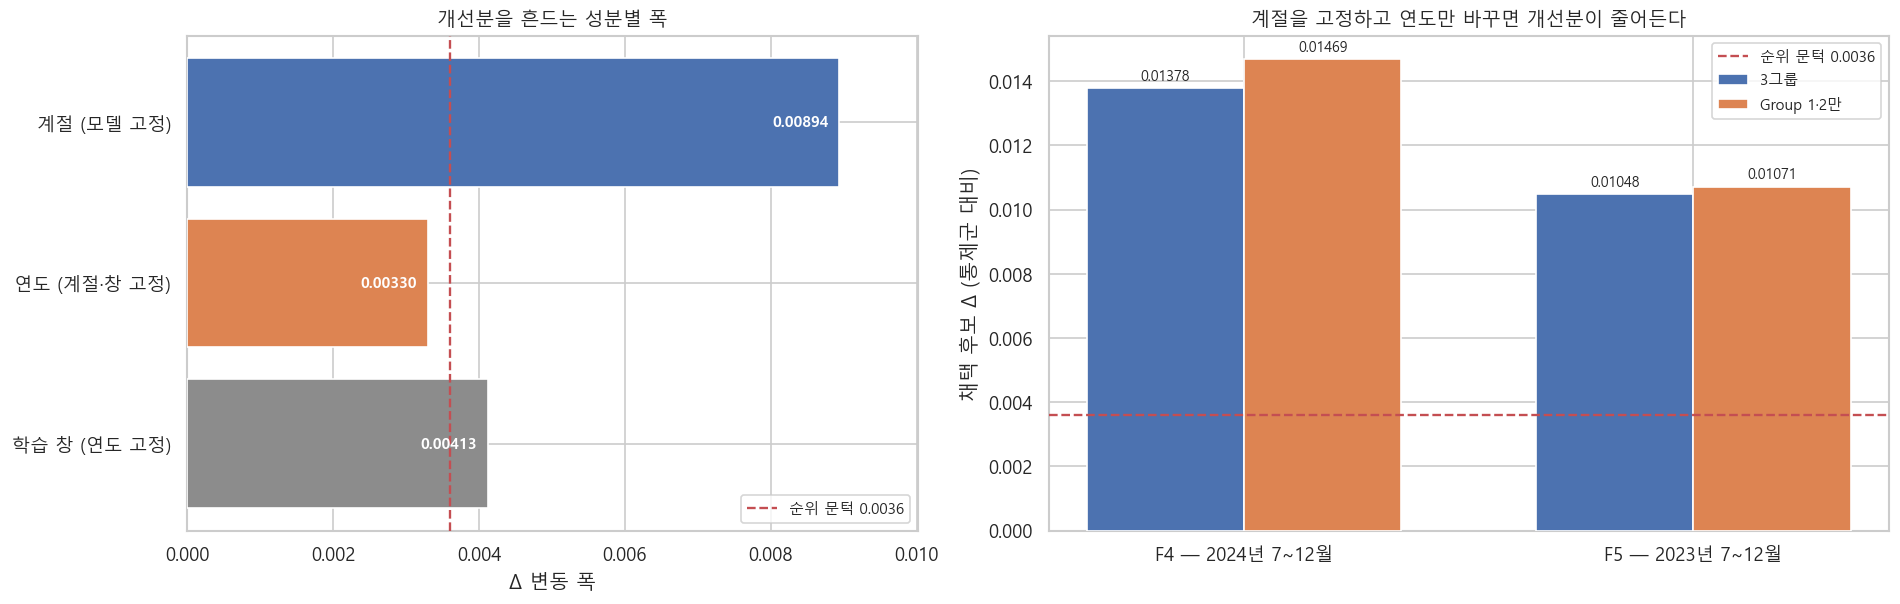

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1, 1.15]})

# barh는 아래에서 위로 그리므로, 큰 성분이 위에 오도록 뒤집어 넣는다.
componentOrder = ["학습 창 (연도 고정)", "연도 (계절·창 고정)", "계절 (모델 고정)"]
axes[0].barh(componentOrder, [componentFrame.loc[name, "폭"] for name in componentOrder],
             color=["#8c8c8c", "#dd8452", "#4c72b0"], zorder=3)
axes[0].axvline(RANK_THRESHOLD, color="#c44e52", linestyle="--", linewidth=1.4, zorder=4,
                label=f"순위 문턱 {RANK_THRESHOLD}")
for position, name in enumerate(componentOrder):
  # 값은 막대 안쪽 끝에 흰 글씨로 적는다. 바깥에 두면 문턱선과 겹친다.
  axes[0].text(componentFrame.loc[name, "폭"] - 0.00015, position,
               f"{componentFrame.loc[name, '폭']:.5f}", va="center", ha="right",
               fontsize=9, color="white", fontweight="bold", zorder=5)
axes[0].set_title("개선분을 흔드는 성분별 폭", fontsize=11.5)
axes[0].set_xlabel("Δ 변동 폭")
axes[0].set_xlim(0, componentFrame["폭"].max() * 1.12)
axes[0].legend(fontsize=9, loc="lower right")

width = 0.35
positions = np.arange(2)
axes[1].bar(positions - width / 2, [candidateDelta["F4"], candidateDelta["F5"]], width,
            label="3그룹", color="#4c72b0", zorder=3)
axes[1].bar(positions + width / 2, [twoGroupDelta["F4"], twoGroupDelta["F5"]], width,
            label="Group 1·2만", color="#dd8452", zorder=3)
axes[1].axhline(RANK_THRESHOLD, color="#c44e52", linestyle="--", linewidth=1.4, zorder=4,
                label=f"순위 문턱 {RANK_THRESHOLD}")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(["F4 — 2024년 7~12월", "F5 — 2023년 7~12월"])
axes[1].set_ylabel("채택 후보 Δ (통제군 대비)")
axes[1].set_title("계절을 고정하고 연도만 바꾸면 개선분이 줄어든다", fontsize=11.5)
axes[1].legend(fontsize=9)
for position, values in zip(positions, [(candidateDelta["F4"], twoGroupDelta["F4"]),
                                        (candidateDelta["F5"], twoGroupDelta["F5"])]):
  for offset, value in zip([-width / 2, width / 2], values):
    axes[1].text(position + offset, value + 0.00025, f"{value:.5f}", ha="center", fontsize=8.5)
plt.tight_layout()
plt.show()

오른쪽 두 쌍이 모두 같은 방향으로 낮아진다. 그룹 수를 바꿔도 결론이 같다.

---

## 7. 종합 결론

### 7-1. 연구 질문

> 검증 구간을 2024 밖으로 옮기는 fold를 만들 수 있는가?

**만들 수 있다.** 노트북 13의 "만들 수 없다"는 판정은 검증 구간을 2023년 달력 전체로
둘 때만 참이었다. 2023년 안에서 자르면 Group 3에도 학습 라벨이 생긴다(F5).
2그룹 채점을 허용하면 순방향으로 2023 전체도 검증할 수 있고(F7), 역방향을 순위 탐침으로
쓰면 2022까지 닿는다(F6·F8). **검증 연도가 1개에서 3개로 늘었다.**

> 프리셋 4종의 순위는 다른 해에서도 유지되는가?

**절반만 유지된다.** 채택 후보가 통제군을 이긴다는 것은 아홉 fold 전부에서 유지되고
fold 내부 bootstrap에서도 P(Δ>0)=1.000이다. 그러나 **1·2위 순위는 2024를 벗어나면
무너진다** — 부호 일치가 5/5에서 8/9로 떨어지고, 2023·2022 fold의 P(간격>0)은
0.429~0.811로 동전 던지기에 가깝다.

### 7-2. 단계별 요약

| 절 | 확인한 것 | 결과 |
|----|-----------|------|
| 1 | 2022 우회로 | UNISON SCADA도 2023 시작 — 복원 불가. 대신 **연내 분할**로 fold 확보 |
| 2 | 2022 창 품질 | 전 연도 NaN 0·cutoff 위반 0. 결측이 교란되지 않는다 |
| 3 | runner 승격 | F0 재현 절대 차이 0.0 — `src/baram/folds.py`가 같은 코드 경로 |
| 4 | 순위 | 통제군 최하위는 9/9 유지. 1·2위는 F6·F7에서 뒤바뀜 |
| 5 | 잡음 판정 | P(Δ>0)=1.000 전 fold / P(간격>0)은 2023·2022에서 0.5 근처 |
| 6 | 연도 성분 | 계절 0.00894 > 학습 창 0.00413 ≈ 연도 0.00330. Group 1·2 재채점으로 교란 배제 |

### 7-3. 주요 발견

1. **"데이터가 없어서 못 한다"는 판정은 한 번 더 의심할 값어치가 있다.** Group 3의 2022
   공백은 실재하고 SCADA로도 못 메운다. 그러나 그 공백이 막는 것은 *특정 형태의 fold*였지
   *모든 cross-year fold*가 아니었다. 검증 구간을 달력 연도와 일치시켜야 한다는 것은
   데이터의 제약이 아니라 우리가 얹은 가정이었다.
2. **부호 일치 5/5는 독립 증거 다섯 개가 아니었다.** 다섯 fold가 같은 해를 검증했으므로
   연도라는 교란이 공통으로 실려 있었다. 검증 연도를 늘리자마자 8/9로 떨어졌고,
   bootstrap은 2023·2022에서 방향 자체가 정해지지 않는다고 말한다.
   설계서 06 5.4절 판정표의 **셋째 칸**이 적용된다.
3. **문턱 0.0036은 고칠 필요가 없다.** 검증 연도를 셋으로 늘려도 Δ의 fold 간 SD가
   0.0035~0.0038 사이에 머문다. 노트북 13이 2024만 보고 정한 값이 우연히 맞은 것은
   아니고, 계절 성분이 이미 가장 큰 흔들림을 담고 있었기 때문이다.
4. **주 결론은 더 단단해졌다.** spatial pooling의 개선분은 세 연도·아홉 fold·양방향에서
   전부 양수이며 최솟값도 문턱의 2.9배다. 이 노트북은 채택을 흔들지 않고
   **채택의 근거를 좁혔다** — "1위라서"가 아니라 "통제군보다 확실히 나아서"다.

### 7-4. 한계

- **역방향 fold(F6·F8)의 수준은 못 쓴다.** Decision Box ㉒대로 순위 탐침으로만 썼다.
  다만 F6가 1·2위 뒤집힘을 처음 보인 fold라, 이 발견이 역방향에만 의존하는지 확인이 필요했다.
  순방향 fold도 F5가 0.670, F7이 0.811로 2024의 0.978~1.000에 한참 못 미치므로,
  결론이 역방향 fold 하나에 걸려 있지는 않다.
- **F5의 Group 3 학습 구간이 6개월뿐이다.** Group 1·2 재채점으로 교란을 배제했지만,
  3그룹 점수에는 여전히 이 비대칭이 남아 있다.
- **fold 아홉 개가 서로 독립이 아니다.** F0·F1·F2는 학습 창을 공유하고 F3·F8도 같은 창을 쓴다.
  부호 일치 8/9를 독립 시행으로 셈하면 안 된다.
- **2022 검증은 2그룹뿐이다.** Group 3의 2022는 어떤 방법으로도 채점할 수 없다.
- **모델은 하나도 바꾸지 않았다.** RandomForest 공식 파라미터 그대로이며 GBM은 범위 밖이다.

### 7-5. 요약

검증 연도를 1개에서 3개로 넓힌 F5~F8을 추가했고, F0가 기존 결과를 절대 차이 0.0으로
재현했다. **채택 후보의 통제군 대비 개선분은 아홉 fold 전부에서 양수**(최소 0.010477,
문턱의 2.9배)이며 fold 내부 bootstrap에서도 예외가 없다. 반면 **1·2위 간격은 2024
밖에서 부호가 흔들리고**(8/9) bootstrap 확률이 0.5 근처로 내려앉는다.
문턱 0.0036은 그대로 유지한다.

### Decision Box ㉓ — 1·2위 순위를 미확정으로 되돌리고, 새 후보는 연도를 건너 확인한다

**선택지**

- (A) 노트북 13의 "잠정 채택"을 유지한다 — 2024에서 부호가 5/5 일치했다
- (B) 1·2위를 **미확정**으로 되돌리고, 앞으로 모든 순위 판정에 cross-year fold를 포함한다
- (C) 채택 후보를 `spatial_nearest_own_group`으로 교체한다

**근거**

(A)의 근거였던 "부호 5/5 일치"는 다섯 fold가 같은 해를 검증한 결과였다. 연도를 늘리자
8/9가 되고 bootstrap은 방향이 정해지지 않는다고 말한다. 설계서 06 5.4절 판정표의
셋째 칸 — **간격 ≤ 문턱이고 부호가 흔들리면 순위 미확정** — 이 정확히 이 상황이다.

(C)는 근거가 없다. 뒤집힌 fold의 간격이 −0.000171이고 bootstrap P가 0.428이므로,
2위가 더 낫다는 주장 역시 잡음과 구분되지 않는다. **어느 쪽도 확정할 수 없다**는 것이
데이터가 말하는 전부다.

제출물은 바꾸지 않는다. `spatial_idw2_all_group`는 통제군 대비 개선분이 아홉 fold에서
확정적이므로 채택을 유지할 근거가 충분하고, 교체할 근거는 없다. 바뀌는 것은 **주장의
범위**다 — "1위 프리셋"이 아니라 "통제군보다 확실히 나은 프리셋 두 개 중 하나"다.

**채택: (B)** — 운영 규칙에 한 줄을 더한다.

| 상황 | 판정 |
|------|------|
| 간격 > 0.0036 | 순위 확정 |
| 간격 ≤ 0.0036 이지만 **모든 검증 연도에서** 부호 일치 | 잠정 채택 |
| 간격 ≤ 0.0036 이고 부호가 흔들림 | 순위 미확정 — 더 단순한 후보 유지 |

굵게 표시한 부분이 이 노트북이 고친 곳이다. "모든 fold"로는 부족하고
**fold가 검증 연도를 최소 둘 이상 덮어야** 한다.

---

## 산출물 확인

In [14]:
print("이 노트북이 쓴 파일 : 없음 (분석 전용)")
print(f"학습한 모델        : {len(predictionCache)}회 (메모리에만 존재, 저장하지 않음)")
print(f"읽은 원자료        : train_labels, ldaps_train, gfs_train, scada 2종, info.xlsx")
print()
print(f"fold 계약 통과      : {contractOk}")
print(f"F0 재현 게이트 통과 : {promotionOk}")
print(f"검증 연도           : {sorted({spec.valid_year for spec in FOLDS.values()})}")
print(f"채택 후보 Δ 최솟값  : {candidateDelta.min():.6f} (문턱 {RANK_THRESHOLD}의 {candidateDelta.min() / RANK_THRESHOLD:.1f}배)")
print(f"1·2위 부호 일치     : {int((gapTopTwo > 0).sum())}/{len(gapTopTwo)}")

이 노트북이 쓴 파일 : 없음 (분석 전용)
학습한 모델        : 24회 (메모리에만 존재, 저장하지 않음)
읽은 원자료        : train_labels, ldaps_train, gfs_train, scada 2종, info.xlsx

fold 계약 통과      : True
F0 재현 게이트 통과 : True
검증 연도           : [2022, 2023, 2024]
채택 후보 Δ 최솟값  : 0.010477 (문턱 0.0036의 2.9배)
1·2위 부호 일치     : 8/9


이 노트북은 파일을 만들지 않는다. 모델도 제출물도 저장하지 않으며 원자료와 라벨은
읽기만 했다.

다음 단계는 설계서 04 7.1절의 M2 — LightGBM/CatBoost 도입이다. 이번 결과가 그 작업의
전제를 바꾼다. **GBM은 후보를 수십 개로 늘리는데, 2024만 검증하는 fold 세트는
"부호 전부 일치"라는 확신을 계속 발급한다.** 이 노트북이 그 실패 모드를 실물로 보였으므로,
GBM 후보는 처음부터 F0~F8 아홉 fold에서 채점하고 Decision Box ㉓의 규칙으로 판정한다.